# Machine Learning Exam Assignment

## Setup
In order for the code to work, we'll need to import a number of packages, which will require our environment to run properly.

Our environment can be created with the following command in the terminal:

`conda env create -f exam.yml -n Exam`

**Note:** This assumes that the terminal is set to the directory containing this file.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn import preprocessing

seed = 0

In [2]:
small_data, small_meta = arff.loadarff('data/BreastCancerAll-Reduced-WithMissingValues.arff')
small_df = pd.DataFrame(data=small_data)
small_df.info()
small_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   302_chrom1_reg44816452-46047207_probnorm      157 non-null    float64
 1   1195_chrom2_reg15573647-20346474_probgain     157 non-null    float64
 2   1441_chrom2_reg126478953-126745976_probloss   157 non-null    float64
 3   1471_chrom2_reg131945577-132042781_probgain   157 non-null    float64
 4   1673_chrom3_reg12735694-14873985_probloss     157 non-null    float64
 5   1966_chrom3_reg128485208-128664764_probnorm   157 non-null    float64
 6   1975_chrom3_reg130189196-130206126_probgain   157 non-null    float64
 7   2007_chrom3_reg143686906-144718154_probgain   157 non-null    float64
 8   2019_chrom3_reg156981865-159692979_probgain   157 non-null    float64
 9   2054_chrom3_reg166639991-168786545_probnorm   157 non-null    float64
 10  2

,302_chrom1_reg44816452-46047207_probnorm,1195_chrom2_reg15573647-20346474_probgain,1441_chrom2_reg126478953-126745976_probloss,1471_chrom2_reg131945577-132042781_probgain,1673_chrom3_reg12735694-14873985_probloss,1966_chrom3_reg128485208-128664764_probnorm,1975_chrom3_reg130189196-130206126_probgain,2007_chrom3_reg143686906-144718154_probgain,2019_chrom3_reg156981865-159692979_probgain,2054_chrom3_reg166639991-168786545_probnorm,...,9605_chrom17_reg35344057-35385941_probloss,9725_chrom17_reg41458670-41494331_probloss,9945_chrom17_reg49218134-49331755_probloss,10674_chrom18_reg64796820-68375250_probnorm,11613_chrom21_reg13660680-14258259_probloss,11969_chrom22_reg41221190-41290227_probloss,11987_chrom22_reg42652021-43322780_probgain,12034_chrom23_reg384298-385792_probnorm,12038_chrom23_reg422315-462468_probnorm,class
0,0.979,0.005,0.009,0.006,0.008,0.975,0.016,0.016,0.016,0.976,...,0.022,0.022,0.022,0.960,0.000,0.824,0.000,0.765,0.765,b'HR+'
1,0.979,0.006,1.000,0.000,0.009,0.000,0.971,0.943,0.943,0.000,...,0.000,0.026,0.016,0.000,0.000,0.991,0.000,0.012,0.012,b'HR+'
2,0.978,0.006,0.007,0.007,0.007,0.985,0.007,0.007,0.007,0.985,...,0.023,0.016,0.016,0.947,0.001,0.999,0.000,0.838,0.838,b'HR+'
3,0.000,0.651,0.069,0.001,1.000,0.000,0.071,0.000,0.025,0.969,...,0.000,1.000,0.903,0.973,0.043,0.093,0.004,0.134,0.134,b'HER2+'
4,0.978,0.009,0.017,0.003,1.000,0.968,0.026,0.984,0.984,0.973,...,1.000,0.025,0.025,0.000,0.011,0.004,0.131,0.001,0.001,b'TN'


## Data Preprocessing
Missing data has to be identified and imputed, and labels must be encoded to a workable format.

In [3]:
for col in small_df.columns:
    missing_rows = small_df[small_df[col].isnull()].index.tolist()
    if missing_rows:
        print(f"Column '{col}' has missing values at rows: {missing_rows}")
        for row in missing_rows:
            substitute_value = small_df[col].mean()
            small_df.loc[row, col] = substitute_value
            print(f"Missing value substituted with: {substitute_value}")

Column '2170_chrom4_reg833085-843614_probnorm' has missing values at rows: [131]
Missing value substituted with: 0.6876923076923077
Column '2630_chrom4_reg187735989-188875290_probnorm' has missing values at rows: [145]
Missing value substituted with: 0.6830064102564102


In [4]:
X = small_df.drop(columns=['class'])
y = small_df['class']

In [5]:
le = preprocessing.LabelEncoder()
le.fit(y)
le.classes_

array([b'HER2+', b'HR+', b'TN'], dtype=object)

In [6]:
y_transform = le.transform(y)
y_transform

array([1, 1, 1, 0, 2, 0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1, 2,
       2, 1, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 1, 0,
       2, 1, 0, 2, 0, 1, 0, 0, 0, 1, 2, 2, 1, 1, 0, 2, 2, 2, 1, 1, 1, 0,
       2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 2, 2, 1, 2, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 0, 1, 0, 2, 2, 2, 2, 2, 2,
       2, 2, 2])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y_transform, test_size=0.3, random_state=seed)

In [8]:
def eval_model(model, X, y):
    pred = model.predict(X)
    accuracy = accuracy_score(y, pred)
    precision = precision_score(y, pred, average=None)
    recall = recall_score(y, pred, average=None)
    f1 = f1_score(y, pred, average=None)
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 score: {f1}")

def eval_train(model):
    print("Evaluating with train data...")
    eval_model(model, X_train, y_train)

def eval_test(model):
    print("Evaluating with test data...")
    eval_model(model, X_test, y_test)

## Model training and hyperparameter tuning

I decided to use a grid search to try and increase the accuracy of the model.
What was interesting is that gamma didn't seem to have any impact when using a linear kernel.

Best parameters:  {'C': 0.175, 'gamma': 1e-05}
Best score:       0.872


[Text(0.5, 23.52222222222222, 'gamma'), Text(50.7222222222222, 0.5, 'C')]

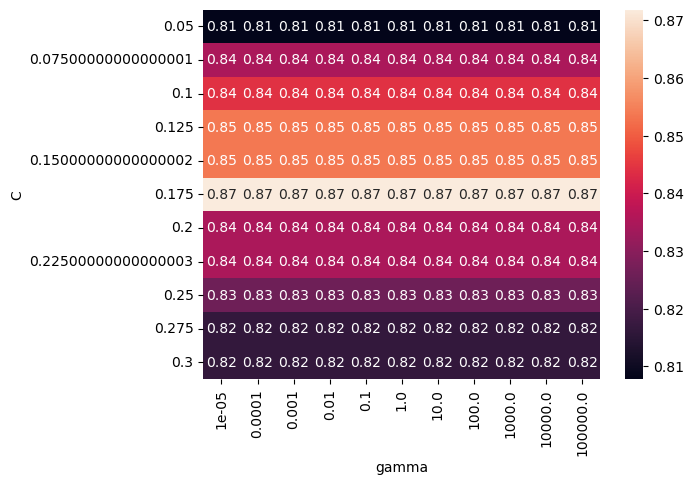

In [9]:
c = [0.025*x + 0.05 for x in range(0, 11)]
g = [np.power(10.0, x) for x in range(-5, 6)]
param_grid = {'C': c, 'gamma': g}
model = SVC(kernel='linear', random_state=seed)

grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_parameters = grid_search.best_params_
best_score = grid_search.best_score_

print("Best parameters:  {}".format(best_parameters))
print("Best score:       {:.3f}".format(best_score))

results = pd.DataFrame(grid_search.cv_results_)

# Reshape test scores and plot heatmap
scores = np.array(results.mean_test_score).reshape(11, 11)
ax = sns.heatmap(scores, xticklabels=param_grid['gamma'], yticklabels=param_grid['C'], annot=True)
ax.set(xlabel='gamma', ylabel='C')

In [10]:
model = grid_search.best_estimator_.fit(X_train, y_train)
pred = model.predict(X_test)

## Evaluating the model

Below, we see that there is a large variance in some of the scores on the test set.
This is most likely due to the small amount of samples. If we had a larger amount of samples, we would most likely have less variance in these numbers.

In [11]:
eval_train(model)

Evaluating with train data...
Accuracy: 0.9357798165137615
Precision: [0.93023256 0.91428571 0.96774194]
Recall: [0.97560976 0.94117647 0.88235294]
F1 score: [0.95238095 0.92753623 0.92307692]


In [12]:
eval_test(model)

Evaluating with test data...
Accuracy: 0.8333333333333334
Precision: [0.88888889 0.77272727 0.88235294]
Recall: [0.88888889 0.85       0.78947368]
F1 score: [0.88888889 0.80952381 0.83333333]


In the confusion matrix below, we can see that our model is pretty good at correctly diagnosing the type of breast cancer.

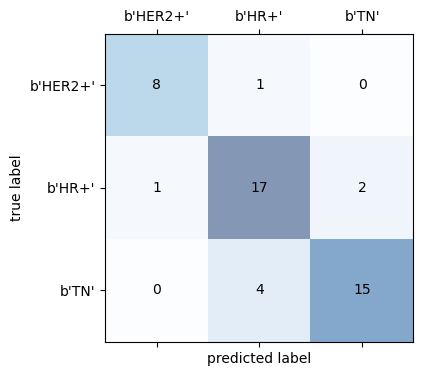

In [13]:
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(4, 4))
ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.5)
ax.set_xticks(np.arange(len(le.classes_)))
ax.set_yticks(np.arange(len(le.classes_)))
ax.set_xticklabels(le.classes_)
ax.set_yticklabels(le.classes_)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,
        s=cm[i, j],
        va='center', ha='center')
plt.xlabel('predicted label')
plt.ylabel('true label')
plt.show()

## Most Important Features

Below, we see the most important features as determined by our model, ranked from most to least important.

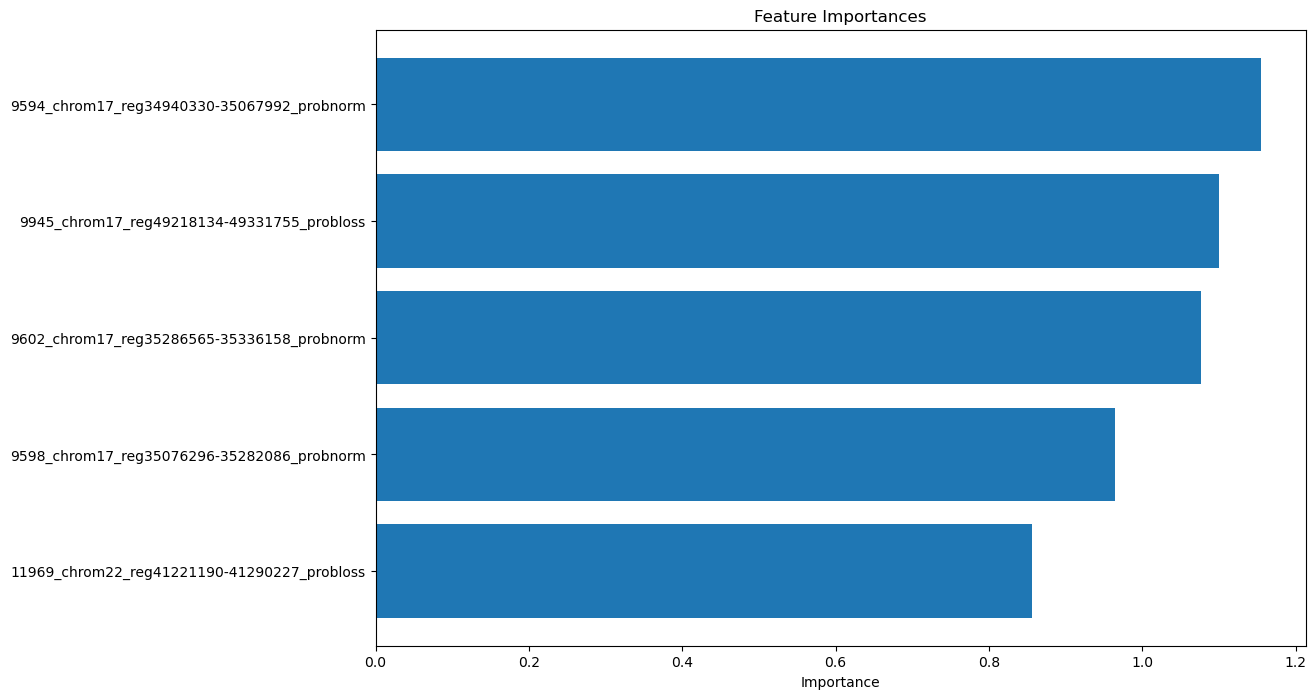

In [14]:
importances = np.abs(model.coef_).sum(axis=0)
indices = np.argsort(importances)[::-1]
top_n = 5

top_indices = indices[:top_n][::-1]
top_importances = importances[top_indices]
top_features = [X_train.columns[i] for i in top_indices]

plt.figure(figsize=(12, 8))
plt.title("Feature Importances")
plt.barh(range(top_n), top_importances)
plt.yticks(range(top_n), top_features)
plt.xlabel("Importance")
plt.show()

## Conclusion

While the model does a decent job of differentiating between different types of breast cancer, two things are important to keep in mind:

**1.** The amount of samples is quite low;

**2.** All samples are of people *already diagnosed* with breast cancer.


This means that the model might not be very reliable, nor can it be properly used to diagnose someone with breast cancer. In order to get a better model, we would want more samples, and we'd like to include samples of people without breast cancer.